# PTA Likelihood vs Pulsar Distance

This notebook demonstrates how the PTA log-likelihood varies as a function of
a single pulsar's distance in the presence of a continuous gravitational wave (CW) source.

We generate **N** random pulsars (white noise + spindown timing models) and
**M** CW sources, then sweep the distance of one pulsar while holding everything
else fixed.

In [ ]:
%matplotlib widget
import matplotlib.pyplot as plt 

In [6]:
from __future__ import annotations

import logging
import warnings

## TEmporarily have PINT shut up with DEBUG and INFO messages 
from loguru import logger
logger.disable("pint")      

from io import StringIO

import jax
import jax.numpy as jnp
import numpy as np

import astropy.units as u
import pint.models as pm
import pint.simulation as psim

from jaxpint import build_timing_model, pint_toas_to_jax
from jaxpint.bridge.model_conversion import pint_model_to_params
from jaxpint.pta.likelihood import PTAConfig, pta_logL
from jaxpint.pta.params import GlobalParams
from jaxpint.pta.signals.cw import CWInjector, cw_delay
from jaxpint.simulation import apply_delay_to_toas

jax.config.update("jax_enable_x64", True)

# ---- Configuration ----
N_PULSARS = 10
M_CW_SOURCES = 100 # Plots up to M CW sources on same graph
N_TOAS = 200         # per pulsar
START_MJD = 57000.0
END_MJD = 60000.0    # ~8 yr observation span
TOA_ERROR = 1e-8     # 10 ns (reduced to make CW signal prominent)
FREQ = 1400.0        # MHz
SEED = 42


## Generate random pulsars

Each pulsar gets a random sky position, spin frequency, spindown rate, DM, and
distance. We build a minimal `.par` string and parse it with PINT.

**Convention:** `CWInjector` reads the `PX` parameter directly as distance in kpc
(not parallax in mas). We set `PX` in the `.par` file accordingly.

In [7]:
rng = np.random.default_rng(SEED)


def generate_random_par(idx: int, rng: np.random.Generator) -> str:
    """Generate a .par string for a simple spindown + white noise pulsar."""
    # Uniform on the sphere
    ra_hours = rng.uniform(0, 24)
    dec_deg = np.degrees(np.arcsin(rng.uniform(-1, 1)))

    ra_h = int(ra_hours)
    ra_m = int((ra_hours - ra_h) * 60)
    ra_s = (ra_hours - ra_h - ra_m / 60) * 3600

    dec_sign = "+" if dec_deg >= 0 else "-"
    dec_abs = abs(dec_deg)
    dec_d = int(dec_abs)
    dec_m = int((dec_abs - dec_d) * 60)
    dec_s = (dec_abs - dec_d - dec_m / 60) * 3600

    f0 = rng.uniform(100, 500)
    f1 = -10 ** rng.uniform(-16, -14)
    dm = rng.uniform(10, 50)
    px_kpc = rng.uniform(0.5, 3.0)  # distance in kpc (stored as PX)

    return f"""\
PSR           J{ra_h:02d}{ra_m:02d}{dec_sign}{dec_d:02d}{dec_m:02d}_{idx:02d}
RAJ           {ra_h:02d}:{ra_m:02d}:{ra_s:08.5f}
DECJ          {dec_sign}{dec_d:02d}:{dec_m:02d}:{dec_s:07.4f}
F0            {f0:.10f}
F1            {f1:.6e}
PEPOCH        {START_MJD:.1f}
DM            {dm:.4f} 
PX            {px_kpc:.4f}
EPHEM         DE440
CLK           TT(BIPM2019)
UNITS         TDB
EFAC tel gbt 1.0
EQUAD tel gbt 0.1
"""


par_strings = [generate_random_par(i, rng) for i in range(N_PULSARS)]
pint_models = [pm.get_model(StringIO(p)) for p in par_strings]

print(f"Generated {N_PULSARS} pulsars")
print(f"Example .par:\n{par_strings[0]}")

Generated 10 pulsars
Example .par:
PSR           J1834-0701_00
RAJ           18:34:29.80260
DECJ          -07:01:17.6778
F0            443.4391679646
F1            -2.481624e-15
PEPOCH        57000.0
DM            13.7671 
PX            2.9391
EPHEM         DE440
CLK           TT(BIPM2019)
UNITS         TDB
EFAC tel gbt 1.0
EQUAD tel gbt 0.1



## Generate fake TOAs and convert to JaxPINT

In [8]:
toa_data_list = []
pulsar_params_list = []
timing_models = []
noise_models = []
pint_toas_list = []  # keep PINT TOAs for fitting

for i, model in enumerate(pint_models):
    toas = psim.make_fake_toas_uniform(
        START_MJD, END_MJD, N_TOAS, model,
        obs="GBT", error=TOA_ERROR * u.s, freq=FREQ * u.MHz,
    )
    toa_data = pint_toas_to_jax(toas, model)
    par_result = pint_model_to_params(model)
    tm, nm = build_timing_model(model, toas)

    toa_data_list.append(toa_data)
    pulsar_params_list.append(par_result.params)
    timing_models.append(tm)
    noise_models.append(nm)
    pint_toas_list.append(toas)

    px_val = float(par_result.params.param_value("PX"))
    print(f"  Pulsar {i}: {model.PSR.value:>20s}  PX(dist)={px_val:.2f} kpc  F0={float(par_result.params.param_value('F0')):.1f} Hz")

print(f"\nAll {N_PULSARS} pulsars loaded.")

/home/hector/NYU/PTA/jax_pint/JaxPINT/.venv/lib/python3.12/site-packages/pint/observatory/clock_file.py:183: UserWarning: Data points out of range in clock file 'tai2tt_bipm2019.clk'
  warn(msg)


  Pulsar 0:        J1834-0701_00  PX(dist)=2.94 kpc  F0=443.4 Hz


/home/hector/NYU/PTA/jax_pint/JaxPINT/.venv/lib/python3.12/site-packages/pint/observatory/clock_file.py:183: UserWarning: Data points out of range in clock file 'tai2tt_bipm2019.clk'
  warn(msg)


  Pulsar 1:        J1816+3453_01  PX(dist)=2.82 kpc  F0=151.2 Hz
  Pulsar 2:        J1527+4012_02  PX(dist)=0.66 kpc  F0=277.4 Hz
  Pulsar 3:        J1951+1516_03  PX(dist)=2.73 kpc  F0=403.2 Hz
  Pulsar 4:        J1840-3738_04  PX(dist)=2.21 kpc  F0=286.7 Hz
  Pulsar 5:        J1752+6913_05  PX(dist)=0.97 kpc  F0=230.3 Hz
  Pulsar 6:        J0307-0247_06  PX(dist)=2.58 kpc  F0=190.8 Hz
  Pulsar 7:        J1648-2202_07  PX(dist)=1.22 kpc  F0=432.9 Hz
  Pulsar 8:        J1622-4605_08  PX(dist)=2.16 kpc  F0=180.0 Hz
  Pulsar 9:        J1655+3409_09  PX(dist)=0.79 kpc  F0=283.6 Hz

All 10 pulsars loaded.


## Set up CW source and PTA config

We place several CW sources at a random sky location with random nHz GW frequency  and
strain amplitude $h \sim 10^{-12}$.

In [9]:
# Compute pulsar unit vectors from RAJ/DECJ
positions = []
for model in pint_models:
    ra_rad = model.RAJ.quantity.to(u.rad).value
    dec_rad = model.DECJ.quantity.to(u.rad).value
    pos = np.array([
        np.cos(dec_rad) * np.cos(ra_rad),
        np.cos(dec_rad) * np.sin(ra_rad),
        np.sin(dec_rad),
    ])
    positions.append(pos)

positions = jnp.array(np.array(positions))

# Generate all CW sources upfront (each with unique sky position & frequency)
all_cw_injectors = []
for m in range(M_CW_SOURCES):
    inj = CWInjector(
        positions,
        prefix=f"cw{m}_",
        initial_values={
            "log10_h": -12.0,
            "cos_gwtheta": rng.uniform(-1, 1),
            "gwphi": rng.uniform(0, 2 * np.pi),
            "log10_fgw": rng.uniform(-9, -7),
        },
    )
    all_cw_injectors.append(inj)
    print(f"  CW source {m}: cos_gwtheta={inj.param_spec['cos_gwtheta']:.3f}, "
          f"gwphi={inj.param_spec['gwphi']:.3f}, "
          f"log10_fgw={inj.param_spec['log10_fgw']:.2f}")

# Save the base (signal-free) TOA data for reuse across M values
base_toa_data_list = list(toa_data_list)
print(f"\nGenerated {M_CW_SOURCES} CW sources total")

  CW source 0: cos_gwtheta=0.337, gwphi=2.960, log10_fgw=-7.87
  CW source 1: cos_gwtheta=0.530, gwphi=3.988, log10_fgw=-7.89
  CW source 2: cos_gwtheta=0.118, gwphi=1.910, log10_fgw=-8.94
  CW source 3: cos_gwtheta=-0.127, gwphi=1.348, log10_fgw=-8.18
  CW source 4: cos_gwtheta=0.707, gwphi=1.470, log10_fgw=-8.88
  CW source 5: cos_gwtheta=-0.437, gwphi=1.845, log10_fgw=-7.68
  CW source 6: cos_gwtheta=0.114, gwphi=4.925, log10_fgw=-7.67
  CW source 7: cos_gwtheta=-0.187, gwphi=5.115, log10_fgw=-8.67
  CW source 8: cos_gwtheta=-0.955, gwphi=0.566, log10_fgw=-7.56
  CW source 9: cos_gwtheta=-0.076, gwphi=1.013, log10_fgw=-8.00
  CW source 10: cos_gwtheta=-0.695, gwphi=4.375, log10_fgw=-8.11
  CW source 11: cos_gwtheta=-0.238, gwphi=1.894, log10_fgw=-7.74
  CW source 12: cos_gwtheta=-0.276, gwphi=0.551, log10_fgw=-8.76
  CW source 13: cos_gwtheta=0.924, gwphi=5.709, log10_fgw=-7.60
  CW source 14: cos_gwtheta=-0.468, gwphi=6.090, log10_fgw=-7.44
  CW source 15: cos_gwtheta=0.434, gwphi=

## Sweep distance for pulsar 0

We vary the distance (PX parameter) of pulsar 0 over a grid while keeping all
other parameters fixed, and evaluate the PTA log-likelihood at each point.

The CW pulsar-term phase depends on distance as
$\phi_p = \phi_e - 2\pi f_{\rm gw} \frac{d}{c}(1 + \cos\mu)$,
so the likelihood oscillates with distance.

In [10]:
TARGET_PULSAR = 0
true_distance = float(pulsar_params_list[TARGET_PULSAR].param_value("PX"))
print(f"Pulsar {TARGET_PULSAR} true distance: {true_distance:.3f} kpc")

half_window = 0.01  # kpc
distance_grid = np.linspace(
    true_distance - half_window,
    true_distance + half_window,
    500,
)
pp_tuple = tuple(pulsar_params_list)

# Sweep for different numbers of CW sources
M_values = [1, 2, 5,10, 20, 50, M_CW_SOURCES]
results = {}  # M -> logL_values

for M in M_values:
    print(f"\n--- M = {M} CW source(s) ---")
    cw_subset = all_cw_injectors[:M]

    # Register params for this subset
    gp = GlobalParams.empty()
    for inj in cw_subset:
        gp = inj.register_params(gp)

    # Inject this subset's CW signals into fresh copies of the base TOAs
    injected_toas = []
    for i in range(N_PULSARS):
        td = base_toa_data_list[i]
        total_delay = jnp.zeros(td.n_toas)
        for inj in cw_subset:
            total_delay += inj.delay(i, td, pulsar_params_list[i], gp)
        injected_toas.append(apply_delay_to_toas(td, total_delay))

    # Build config
    cfg = PTAConfig(
        toa_data_list=tuple(injected_toas),
        timing_models=tuple(timing_models),
        noise_models=tuple(noise_models),
        signal_injectors=tuple(cw_subset),
    )

    @jax.jit
    def _eval(px_value, _gp=gp, _cfg=cfg):
        mod = pp_tuple[TARGET_PULSAR].with_value("PX", px_value)
        pp_mod = pp_tuple[:TARGET_PULSAR] + (mod,) + pp_tuple[TARGET_PULSAR + 1:]
        return pta_logL(_gp, pp_mod, _cfg)

    # Warm up + sweep
    _ = _eval(jnp.float64(true_distance))
    logL_vals = np.array([float(_eval(jnp.float64(d))) for d in distance_grid])
    results[M] = logL_vals
    print(f"  Sweep complete ({len(distance_grid)} points)")

print("\nAll sweeps done.")

Pulsar 0 true distance: 2.939 kpc

--- M = 1 CW source(s) ---


/tmp/ipykernel_55048/861930511.py:36: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  cfg = PTAConfig(


  Sweep complete (500 points)

--- M = 2 CW source(s) ---
  Sweep complete (500 points)

--- M = 5 CW source(s) ---
  Sweep complete (500 points)

--- M = 10 CW source(s) ---
  Sweep complete (500 points)

--- M = 20 CW source(s) ---
  Sweep complete (500 points)

--- M = 50 CW source(s) ---
  Sweep complete (500 points)

--- M = 100 CW source(s) ---
  Sweep complete (500 points)

All sweeps done.


## Plot Likelihood

JaxPINT WLS fitter result for pulsar 0:
  PX = 2.939382 +/- 0.009431 kpc (1-sigma)


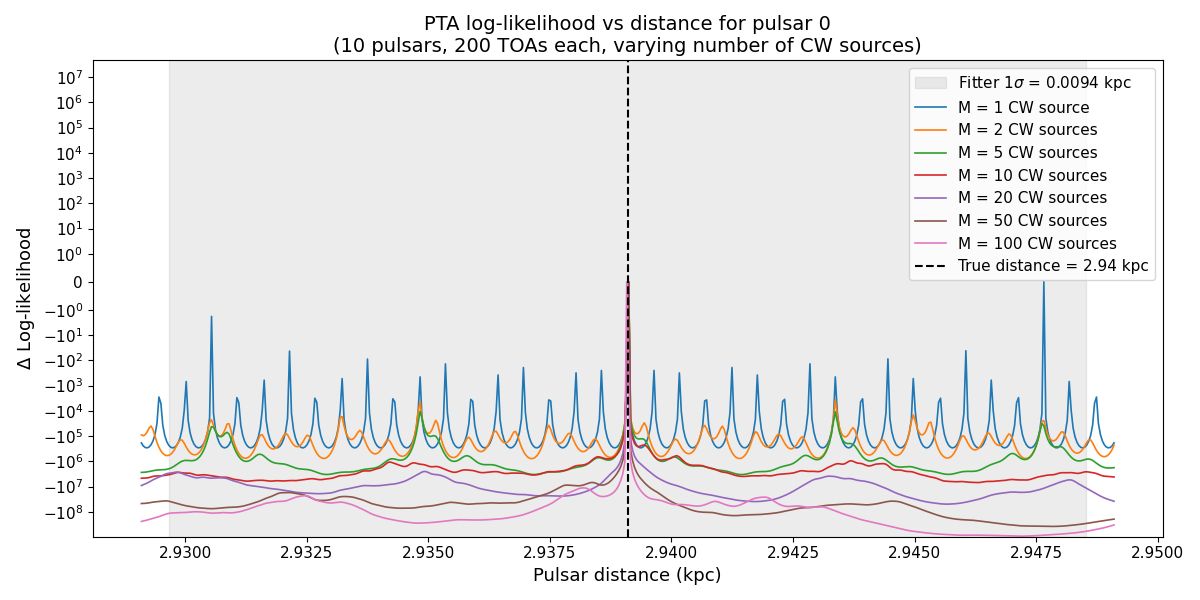

In [17]:
# Fit the target pulsar with JaxPINT's WLS fitter to get PX uncertainty
from jaxpint.fitters import WLSFitter
from jaxpint.types import ParameterVector

# Unfreeze PX so the fitter estimates its uncertainty
target_params = pulsar_params_list[TARGET_PULSAR]
px_idx = target_params.names.index("PX")
new_frozen = list(target_params.frozen_mask)
new_frozen[px_idx] = False
fit_params = ParameterVector(
    values=target_params.values,
    frozen_mask=tuple(new_frozen),
    names=target_params.names,
    units=target_params.units,
    epoch_int_values=target_params.epoch_int_values,
)

fitter = WLSFitter(
    timing_models[TARGET_PULSAR],
    base_toa_data_list[TARGET_PULSAR],
    fit_params,
    noise_models[TARGET_PULSAR],
)
fit_result = fitter.fit_toas()

# Find PX among the free parameters
free_names = [fit_params.names[i] for i in fit_params._free_indices]
px_free_idx = free_names.index("PX")
px_err = float(fit_result.parameter_uncertainties[px_free_idx])

print(f"JaxPINT WLS fitter result for pulsar {TARGET_PULSAR}:")
print(f"  PX = {float(fit_result.params.param_value('PX')):.6f} +/- {px_err:.6f} kpc (1-sigma)")

# Plot with fitter uncertainty band — normalize to delta log-likelihood
fig, ax = plt.subplots(figsize=(12, 6))

ax.axvspan(true_distance - px_err, true_distance + px_err,
           alpha=0.15, color="gray", label=f"Fitter 1$\\sigma$ = {px_err:.4f} kpc")

for M in M_values:
    logL = results[M]
    delta_logL = logL - logL.max()
    ax.plot(distance_grid, delta_logL, linewidth=1.2, label=f"M = {M} CW source{'s' if M > 1 else ''}")

ax.axvline(true_distance, color="black", linestyle="--", linewidth=1.5,
           label=f"True distance = {true_distance:.2f} kpc")

ax.set_yscale("symlog", linthresh=1e0)
ax.set_xlabel("Pulsar distance (kpc)", fontsize=13)
ax.set_ylabel("$\\Delta$ Log-likelihood", fontsize=13)
ax.set_title(
    f"PTA log-likelihood vs distance for pulsar {TARGET_PULSAR}\n"
    f"({N_PULSARS} pulsars, {N_TOAS} TOAs each, varying number of CW sources)",
    fontsize=14,
)
ax.legend(fontsize=11)
ax.tick_params(labelsize=11)
fig.tight_layout()
plt.show()

## Fisher Information Analysis

The Fisher information $F = -\frac{d^2 \log L}{d(\text{PX})^2}$ at the true distance
quantifies how tightly the likelihood constrains the distance. The Cramér-Rao bound
gives the minimum uncertainty: $\sigma_d \geq 1/\sqrt{F}$.

### Fisher information vs number of CW sources


In [ ]:
M_sweep = [1, 2, 5,10, 20, 50, M_CW_SOURCES]
fisher_vs_M = []
sigma_vs_M = []

for M in M_sweep:
    cw_subset = all_cw_injectors[:M]

    gp = GlobalParams.empty()
    for inj in cw_subset:
        gp = inj.register_params(gp)

    injected_toas = []
    for i in range(N_PULSARS):
        td = base_toa_data_list[i]
        total_delay = jnp.zeros(td.n_toas)
        for inj in cw_subset:
            total_delay += inj.delay(i, td, pulsar_params_list[i], gp)
        injected_toas.append(apply_delay_to_toas(td, total_delay))

    cfg = PTAConfig(
        toa_data_list=tuple(injected_toas),
        timing_models=tuple(timing_models),
        noise_models=tuple(noise_models),
        signal_injectors=tuple(cw_subset),
    )

    @jax.jit
    def _eval_fisher(px_value, _gp=gp, _cfg=cfg):
        mod = pp_tuple[TARGET_PULSAR].with_value("PX", px_value)
        pp_mod = pp_tuple[:TARGET_PULSAR] + (mod,) + pp_tuple[TARGET_PULSAR + 1:]
        return pta_logL(_gp, pp_mod, _cfg)

    F = float(-jax.jit(jax.grad(jax.grad(_eval_fisher)))(jnp.float64(true_distance)))
    fisher_vs_M.append(F)
    sigma_vs_M.append(1.0 / np.sqrt(abs(F)))

    if M % 10 == 0 or M <= 5:
        print(f"  M={M:3d}: F={F:.4e}, sigma_d={sigma_vs_M[-1]:.4e} kpc")

fisher_vs_M = np.array(fisher_vs_M)
sigma_vs_M = np.array(sigma_vs_M)
print("Done.")

/tmp/ipykernel_50382/860932491.py:20: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  cfg = PTAConfig(


  M=  1: F=2.0282e+13, sigma_d=2.2205e-07 kpc
  M=  2: F=1.5981e+13, sigma_d=2.5015e-07 kpc
  M=  5: F=1.9666e+13, sigma_d=2.2550e-07 kpc
  M= 10: F=3.4156e+13, sigma_d=1.7111e-07 kpc
  M= 20: F=1.0201e+14, sigma_d=9.9010e-08 kpc
  M= 50: F=2.5445e+14, sigma_d=6.2690e-08 kpc
  M=100: F=7.3875e+14, sigma_d=3.6792e-08 kpc
Done.


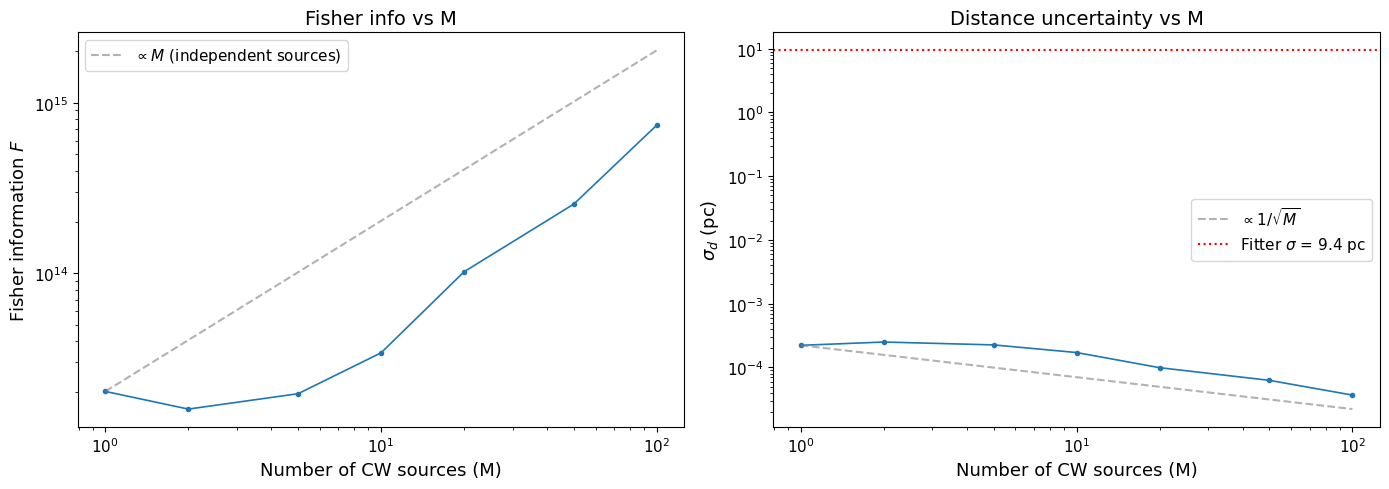

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Fisher info vs M
ax1.loglog(M_sweep, fisher_vs_M, "o-", markersize=3, linewidth=1.2)
# Reference: linear scaling from M=1
ax1.loglog(M_sweep, fisher_vs_M[0] * np.array(M_sweep), "--", color="gray",
           alpha=0.6, label="$\\propto M$ (independent sources)")
ax1.set_xlabel("Number of CW sources (M)", fontsize=13)
ax1.set_ylabel("Fisher information $F$", fontsize=13)
ax1.set_title("Fisher info vs M", fontsize=14)
ax1.legend(fontsize=11)
ax1.tick_params(labelsize=11)

# sigma_d vs M
ax2.loglog(M_sweep, sigma_vs_M * 1e3, "o-", markersize=3, linewidth=1.2)  # convert to pc
ax2.loglog(M_sweep, sigma_vs_M[0] * 1e3 / np.sqrt(M_sweep), "--", color="gray",
           alpha=0.6, label="$\\propto 1/\\sqrt{M}$")
ax2.axhline(px_err * 1e3, color="red", linestyle=":", linewidth=1.5,
            label=f"Fitter $\\sigma$ = {px_err*1e3:.1f} pc")
ax2.set_xlabel("Number of CW sources (M)", fontsize=13)
ax2.set_ylabel("$\\sigma_d$ (pc)", fontsize=13)  
ax2.set_title("Distance uncertainty vs M", fontsize=14)
ax2.legend(fontsize=11)
ax2.tick_params(labelsize=11)

fig.tight_layout()
plt.show()

### Fisher information vs GW frequency

Fix M=1 and sweep the CW source frequency. Higher frequency means faster
distance oscillations (shorter wavelength in distance space), which should
increase the local curvature of the likelihood peak.

In [ ]:
# Use CW source 0 as a template, varying only log10_fgw
template_spec = dict(all_cw_injectors[0].param_spec)

log10_fgw_grid = np.linspace(-9, -7, 40)
fisher_vs_freq = []
sigma_vs_freq = []

for log10_f in log10_fgw_grid:
    spec = dict(template_spec)
    spec["log10_fgw"] = float(log10_f)

    inj = CWInjector(positions, prefix="cwfreq_", initial_values=spec)
    gp = inj.register_params(GlobalParams.empty())

    injected_toas = []
    for i in range(N_PULSARS):
        td = base_toa_data_list[i]
        delay = inj.delay(i, td, pulsar_params_list[i], gp)
        injected_toas.append(apply_delay_to_toas(td, delay))

    cfg = PTAConfig(
        toa_data_list=tuple(injected_toas),
        timing_models=tuple(timing_models),
        noise_models=tuple(noise_models),
        signal_injectors=(inj,),
    )

    @jax.jit
    def _eval_freq(px_value, _gp=gp, _cfg=cfg):
        mod = pp_tuple[TARGET_PULSAR].with_value("PX", px_value)
        pp_mod = pp_tuple[:TARGET_PULSAR] + (mod,) + pp_tuple[TARGET_PULSAR + 1:]
        return pta_logL(_gp, pp_mod, _cfg)

    F = float(-jax.jit(jax.grad(jax.grad(_eval_freq)))(jnp.float64(true_distance)))
    fisher_vs_freq.append(F)
    sigma_vs_freq.append(1.0 / np.sqrt(abs(F)))

fisher_vs_freq = np.array(fisher_vs_freq)
sigma_vs_freq = np.array(sigma_vs_freq)
print("Done.")

/tmp/ipykernel_50382/2178740848.py:21: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  cfg = PTAConfig(


Done.


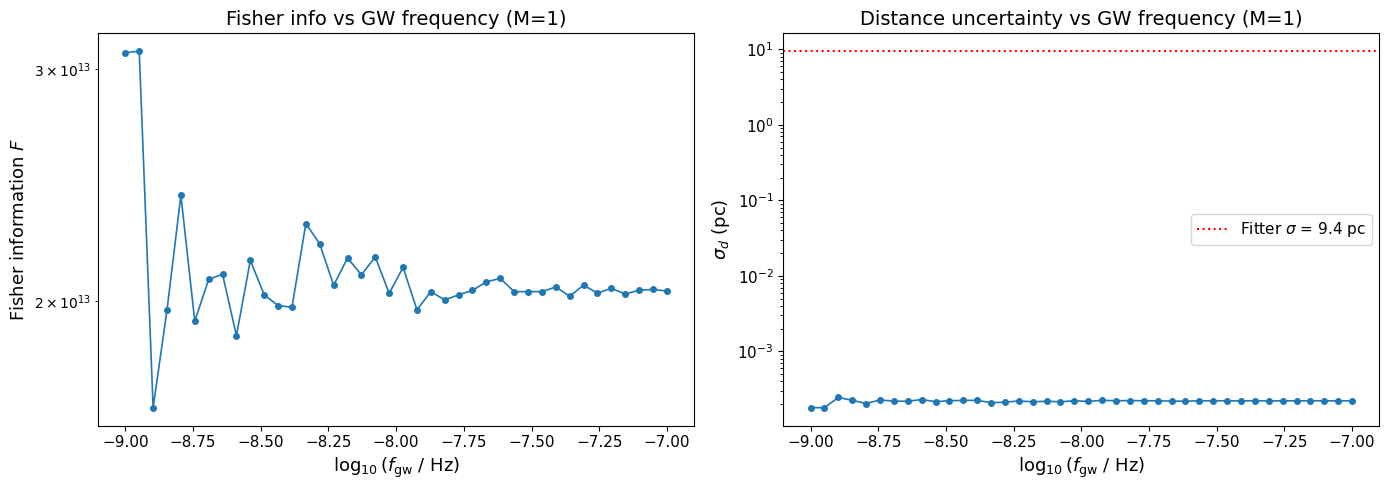

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.semilogy(log10_fgw_grid, fisher_vs_freq, "o-", markersize=4, linewidth=1.2)
ax1.set_xlabel("$\\log_{10}(f_{\\rm gw}$ / Hz)", fontsize=13)
ax1.set_ylabel("Fisher information $F$", fontsize=13)
ax1.set_title("Fisher info vs GW frequency (M=1)", fontsize=14)
ax1.tick_params(labelsize=11)

ax2.semilogy(log10_fgw_grid, sigma_vs_freq * 1e3, "o-", markersize=4, linewidth=1.2)
ax2.axhline(px_err * 1e3, color="red", linestyle=":", linewidth=1.5,
            label=f"Fitter $\\sigma$ = {px_err*1e3:.1f} pc")
ax2.set_xlabel("$\\log_{10}(f_{\\rm gw}$ / Hz)", fontsize=13)
ax2.set_ylabel("$\\sigma_d$ (pc)", fontsize=13)
ax2.set_title("Distance uncertainty vs GW frequency (M=1)", fontsize=14)
ax2.legend(fontsize=11)
ax2.tick_params(labelsize=11)

fig.tight_layout()
plt.show()

### Fisher information vs CW strain amplitude

Fix M=1 and sweep `log10_h`. Since the CW delay scales as $h / (2\pi f_{\rm gw})$,
the signal-to-noise ratio scales linearly with $h$, so we expect $F \propto h^2$.

In [ ]:
# Use CW source 0 as a template, varying only log10_h
template_spec_h = dict(all_cw_injectors[0].param_spec)

log10_h_grid = np.linspace(-15, -11, 40)
fisher_vs_h = []
sigma_vs_h = []

for log10_h in log10_h_grid:
    spec = dict(template_spec_h)
    spec['log10_h'] = float(log10_h)

    inj = CWInjector(positions, prefix='cwamp_', initial_values=spec)
    gp = inj.register_params(GlobalParams.empty())

    injected_toas = []
    for i in range(N_PULSARS):
        td = base_toa_data_list[i]
        delay = inj.delay(i, td, pulsar_params_list[i], gp)
        injected_toas.append(apply_delay_to_toas(td, delay))

    cfg = PTAConfig(
        toa_data_list=tuple(injected_toas),
        timing_models=tuple(timing_models),
        noise_models=tuple(noise_models),
        signal_injectors=(inj,),
    )

    @jax.jit
    def _eval_amp(px_value, _gp=gp, _cfg=cfg):
        mod = pp_tuple[TARGET_PULSAR].with_value('PX', px_value)
        pp_mod = pp_tuple[:TARGET_PULSAR] + (mod,) + pp_tuple[TARGET_PULSAR + 1:]
        return pta_logL(_gp, pp_mod, _cfg)

    F = float(-jax.jit(jax.grad(jax.grad(_eval_amp)))(jnp.float64(true_distance)))
    fisher_vs_h.append(F)
    sigma_vs_h.append(1.0 / np.sqrt(abs(F)))

fisher_vs_h = np.array(fisher_vs_h)
sigma_vs_h = np.array(sigma_vs_h)
print('Done.')

/tmp/ipykernel_50382/2495837885.py:21: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  cfg = PTAConfig(


Done.


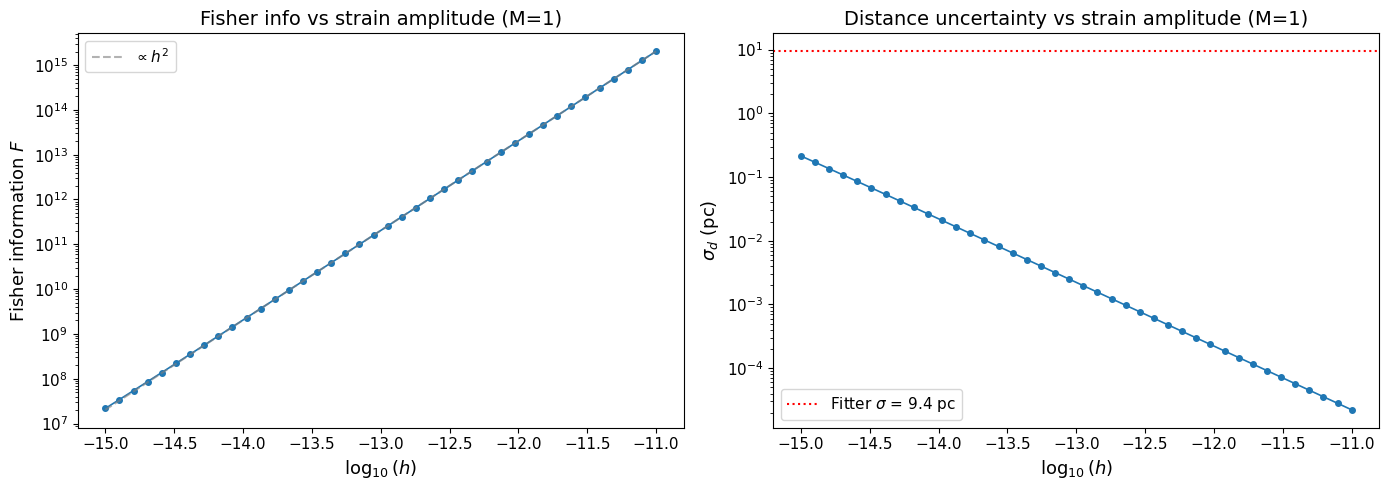

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.semilogy(log10_h_grid, fisher_vs_h, 'o-', markersize=4, linewidth=1.2)
# Reference: h^2 scaling
h_ref = 10.0 ** log10_h_grid
h0 = 10.0 ** log10_h_grid[len(log10_h_grid)//2]
F0 = fisher_vs_h[len(log10_h_grid)//2]
ax1.semilogy(log10_h_grid, F0 * (h_ref / h0)**2, '--', color='gray',
             alpha=0.6, label='$\\propto h^2$')
ax1.set_xlabel('$\\log_{10}(h)$', fontsize=13)
ax1.set_ylabel('Fisher information $F$', fontsize=13)
ax1.set_title('Fisher info vs strain amplitude (M=1)', fontsize=14)
ax1.legend(fontsize=11)
ax1.tick_params(labelsize=11)

ax2.semilogy(log10_h_grid, sigma_vs_h * 1e3, 'o-', markersize=4, linewidth=1.2)
ax2.axhline(px_err * 1e3, color='red', linestyle=':', linewidth=1.5,
            label=f'Fitter $\\sigma$ = {px_err*1e3:.1f} pc')
ax2.set_xlabel('$\\log_{10}(h)$', fontsize=13)
ax2.set_ylabel('$\\sigma_d$ (pc)', fontsize=13)
ax2.set_title('Distance uncertainty vs strain amplitude (M=1)', fontsize=14)
ax2.legend(fontsize=11)
ax2.tick_params(labelsize=11)

fig.tight_layout()
plt.show()